In [1]:
import pandas as pd
import numpy as np
print("Hello, VS Code + Jupyter is working!")


Hello, VS Code + Jupyter is working!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

print("All libraries working fine!")


All libraries working fine!


In [8]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_samples = 10000

data = pd.DataFrame({
    "BoardID": range(1, n_samples+1),
    "BatchID": np.random.choice(["BatchA", "BatchB", "BatchC", "BatchD"], n_samples),
    "MCU_Type": np.random.choice(["STM32", "PIC32", "AVR", "ESP32"], n_samples),
    "ClockSpeed_MHz": np.random.normal(48, 2, n_samples),
    "Flash_Memory_MB": np.random.normal(4, 0.5, n_samples),
    "Power_Consumption_mW": np.random.normal(500, 50, n_samples),
    "IO_Pins_Passed": np.random.randint(30, 41, n_samples), # out of 40
    "Temperature_C": np.random.normal(50, 8, n_samples),
    "Voltage_V": np.random.normal(3.3, 0.2, n_samples),
    "TestDuration_s": np.random.normal(120, 10, n_samples),
})

# Defect logic (realistic)
data["DefectLabel"] = (
    (data["ClockSpeed_MHz"] < 45) |
    (data["Power_Consumption_mW"] > 600) |
    (data["IO_Pins_Passed"] < 35) |
    (data["Temperature_C"] > 70) |
    (data["Voltage_V"] < 3.0)
).astype(int)

# Add ~3% random label noise for realism
noise = np.random.rand(len(data)) < 0.03
data.loc[noise, "DefectLabel"] = 1 - data.loc[noise, "DefectLabel"]

print("Noise added:", noise.sum(), "rows flipped")

# Save
data.to_csv("../data/production_test_data.csv", index=False)

print("New microcontroller board dataset created:", data.shape)
data.head()


Noise added: 300 rows flipped
New microcontroller board dataset created: (10000, 11)


,BoardID,BatchID,MCU_Type,ClockSpeed_MHz,Flash_Memory_MB,Power_Consumption_mW,IO_Pins_Passed,Temperature_C,Voltage_V,TestDuration_s,DefectLabel
0,1,BatchC,AVR,45.024277,3.691926,539.184097,39,40.898114,3.328926,108.984251,0
1,2,BatchD,ESP32,45.749628,3.803663,500.376932,32,72.648435,3.149109,117.664585,1
2,3,BatchA,AVR,48.777638,3.484087,532.740660,32,47.179668,3.387299,96.338294,1
3,4,BatchC,ESP32,45.652253,3.555374,449.284148,40,56.223475,3.250581,128.168906,0
4,5,BatchC,ESP32,50.225269,4.217188,507.169313,36,57.896460,3.027757,132.570295,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   BoardID               10000 non-null  int64  
 1   BatchID               10000 non-null  object 
 2   MCU_Type              10000 non-null  object 
 3   ClockSpeed_MHz        10000 non-null  float64
 4   Flash_Memory_MB       10000 non-null  float64
 5   Power_Consumption_mW  10000 non-null  float64
 6   IO_Pins_Passed        10000 non-null  int64  
 7   Temperature_C         10000 non-null  float64
 8   Voltage_V             10000 non-null  float64
 9   TestDuration_s        10000 non-null  float64
 10  DefectLabel           10000 non-null  int64  
dtypes: float64(6), int64(3), object(2)
memory usage: 859.5+ KB
None
           BoardID  ClockSpeed_MHz  Flash_Memory_MB  Power_Consumption_mW  \
count  10000.00000    10000.000000     10000.000000          10000.000000   
mean  

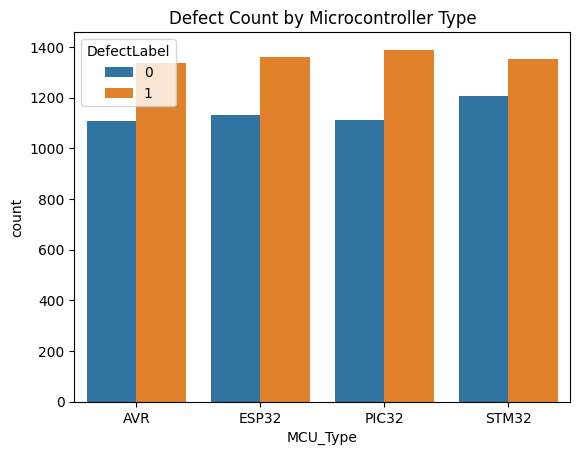

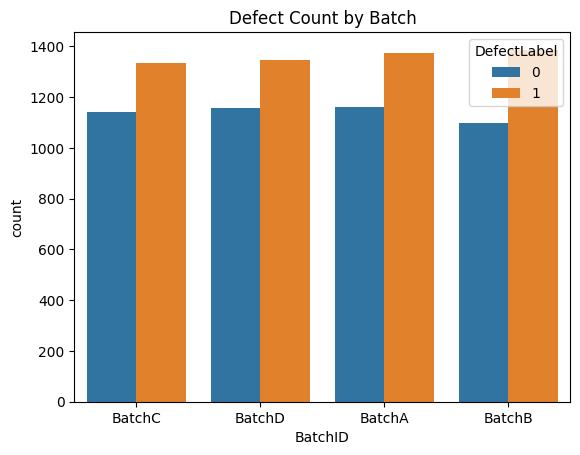

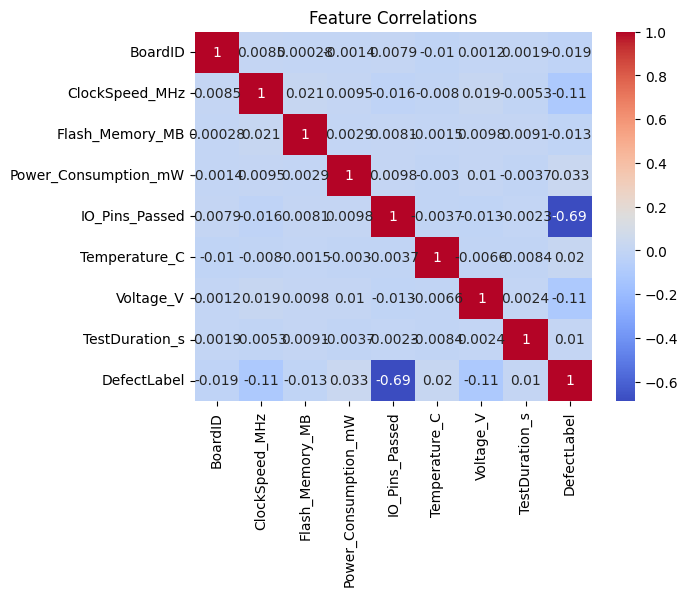

In [10]:
# Load new dataset
df = pd.read_csv("../data/production_test_data.csv")

# Quick look
print(df.info())
print(df.describe())
print("Defect Rate:", df['DefectLabel'].mean())

# Distribution of MCU Types
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="MCU_Type", hue="DefectLabel")
plt.title("Defect Count by Microcontroller Type")
plt.show()

# Defect rate by Batch
sns.countplot(data=df, x="BatchID", hue="DefectLabel")
plt.title("Defect Count by Batch")
plt.show()

# Correlation heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlations")
plt.show()
